# Evaluacion del mejor estimador de centro $\theta$

Este notebook compara los tres estimadores de centro usados en el proyecto:

- `argmin`: estimador que minimiza el estadistico $T_n$.
- `median`: mediana muestral.
- `trimmed`: media afeitada al 10%.

La decision se basa principalmente en escenarios bajo $H_0$, porque ahi el centro verdadero es conocido ($\theta=2$ para Uniforme(1,3) y Cauchy(loc=2, scale=1)). En escenarios bajo $H_a$ no existe un centro de simetria verdadero, asi que se reportan solo como diagnostico de estabilidad.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

DATA_DIR = ROOT / 'results' / 'data'
FIG_DIR = ROOT / 'results' / 'figures'
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

ESTIMATOR_ORDER = ['argmin', 'median', 'trimmed']
ESTIMATOR_LABELS = {
    'argmin': r'$\hat\theta_{\min}$',
    'median': r'$\hat\theta_{\mathrm{med}}$',
    'trimmed': r'$\hat\theta_{\alpha}$',
}
ESTIMATOR_COLORS = {'argmin': 'C0', 'median': 'C1', 'trimmed': 'C2'}

print(f'Working dir: {Path.cwd()}')

Working dir: c:\Users\juanc\github\Proyecto2EstadisticaNP


## Cargar o regenerar datos

Por defecto se cargan `results/data/estimator_quality_raw.csv` y `results/data/estimator_quality_summary.csv`. Si no existen, el notebook puede regenerarlos con `run_quality_simulation`.

In [2]:
raw_path = DATA_DIR / 'estimator_quality_raw.csv'
summary_path = DATA_DIR / 'estimator_quality_summary.csv'

# Cambiar a True para forzar una simulacion nueva.
force_rerun = False

if force_rerun or not summary_path.exists() or not raw_path.exists():
    from src.simulation_estimators import run_quality_simulation, summarize_quality

    raw = run_quality_simulation(sample_sizes=(20, 40, 80, 160), R=500, seed=2026)
    summary = summarize_quality(raw)

    # Intervalo intercuartilico para diagnosticos graficos.
    q = (
        raw.groupby(['dist', 'under_h0', 'theta_true', 'n', 'estimator'])['theta_hat']
        .quantile([0.25, 0.75])
        .unstack()
        .rename(columns={0.25: 'q25', 0.75: 'q75'})
        .reset_index()
    )
    summary = summary.merge(q, on=['dist', 'under_h0', 'theta_true', 'n', 'estimator'], how='left')

    raw.to_csv(raw_path, index=False)
    summary.to_csv(summary_path, index=False)
else:
    raw = pd.read_csv(raw_path)
    summary = pd.read_csv(summary_path)

summary['under_h0'] = summary['under_h0'].astype(bool)
raw['under_h0'] = raw['under_h0'].astype(bool)

print(f'Raw: {len(raw):,} filas')
print(f'Summary: {len(summary):,} filas')
display(summary.head())

Raw: 30,000 filas
Summary: 60 filas


,dist,under_h0,theta_true,n,estimator,mean_hat,std_hat,q25,q75,bias,rmse,mae
0,"Cauchy(loc=2.0,scale=1.0)",True,2.0,20,argmin,1.988563,0.416792,1.727367,2.251636,-0.011437,0.416533,0.322450
1,"Cauchy(loc=2.0,scale=1.0)",True,2.0,20,median,2.000318,0.356057,1.782219,2.232402,0.000318,0.355701,0.279198
2,"Cauchy(loc=2.0,scale=1.0)",True,2.0,20,trimmed,2.009949,0.572146,1.733755,2.324390,0.009949,0.571660,0.409008
3,"Cauchy(loc=2.0,scale=1.0)",True,2.0,40,argmin,2.007928,0.267302,1.857906,2.169942,0.007928,0.267152,0.206468
4,"Cauchy(loc=2.0,scale=1.0)",True,2.0,40,median,2.000089,0.246617,1.833930,2.159295,0.000089,0.246370,0.192570


## Criterio de comparacion

Bajo $H_0$ se conoce $\theta=2$, por lo que se comparan:

- `rmse`: criterio principal; penaliza errores grandes.
- `mae`: criterio robusto complementario.
- `abs_bias`: magnitud del sesgo promedio.

El ranking compuesto usa pesos conservadores: 60% RMSE, 30% MAE y 10% sesgo absoluto.

In [3]:
h0 = summary[summary['under_h0']].copy()
h0['abs_bias'] = h0['bias'].abs()

metrics = ['rmse', 'mae', 'abs_bias']
ranked = h0.copy()
for metric in metrics:
    ranked[f'{metric}_rank'] = ranked.groupby(['dist', 'n'])[metric].rank(method='min')

ranked['score'] = (
    0.60 * ranked['rmse_rank']
    + 0.30 * ranked['mae_rank']
    + 0.10 * ranked['abs_bias_rank']
)

mean_metrics = (
    h0.groupby('estimator')[metrics]
    .mean()
    .loc[ESTIMATOR_ORDER]
    .sort_values('rmse')
)

mean_ranks = (
    ranked.groupby('estimator')[['rmse_rank', 'mae_rank', 'abs_bias_rank', 'score']]
    .mean()
    .loc[ESTIMATOR_ORDER]
    .sort_values('score')
)

display(Markdown('### Promedios bajo $H_0$'))
display(mean_metrics)
display(Markdown('### Ranking promedio bajo $H_0$ (menor es mejor)'))
display(mean_ranks)

### Promedios bajo $H_0$

,rmse,mae,abs_bias
estimator,,,
argmin,0.171005,0.134567,0.005584
median,0.182221,0.145273,0.006124
trimmed,0.219230,0.165852,0.006360


### Ranking promedio bajo $H_0$ (menor es mejor)

,rmse_rank,mae_rank,abs_bias_rank,score
estimator,,,,
argmin,1.625,1.625,1.625,1.625
median,2.000,2.000,2.500,2.050
trimmed,2.375,2.375,1.875,2.325


In [4]:
winner_tables = []
for metric in metrics:
    idx = h0.groupby(['dist', 'n'])[metric].idxmin()
    winners = h0.loc[idx, ['dist', 'n', 'estimator', metric]].copy()
    winners['metric'] = metric
    winners = winners.rename(columns={metric: 'value'})
    winner_tables.append(winners)

winners_long = pd.concat(winner_tables, ignore_index=True)
winner_counts = (
    winners_long.groupby(['metric', 'estimator'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=ESTIMATOR_ORDER, fill_value=0)
)

display(Markdown('### Ganadores por distribucion y tamano muestral'))
display(winners_long.sort_values(['metric', 'dist', 'n']))
display(Markdown('### Numero de victorias por metrica'))
display(winner_counts)

### Ganadores por distribucion y tamano muestral

,dist,n,estimator,value,metric
16,"Cauchy(loc=2.0,scale=1.0)",20,median,0.000318,abs_bias
17,"Cauchy(loc=2.0,scale=1.0)",40,median,0.000089,abs_bias
18,"Cauchy(loc=2.0,scale=1.0)",80,argmin,0.005237,abs_bias
19,"Cauchy(loc=2.0,scale=1.0)",160,trimmed,0.001634,abs_bias
20,"Uniforme(1.0,3.0)",20,argmin,0.010805,abs_bias
21,"Uniforme(1.0,3.0)",40,trimmed,0.001226,abs_bias
22,"Uniforme(1.0,3.0)",80,argmin,0.000399,abs_bias
23,"Uniforme(1.0,3.0)",160,argmin,0.000669,abs_bias
8,"Cauchy(loc=2.0,scale=1.0)",20,median,0.279198,mae
9,"Cauchy(loc=2.0,scale=1.0)",40,median,0.192570,mae


### Numero de victorias por metrica

estimator,argmin,median,trimmed
metric,,,
abs_bias,4,2,2
mae,3,4,1
rmse,3,4,1


## Figuras bajo $H_0$

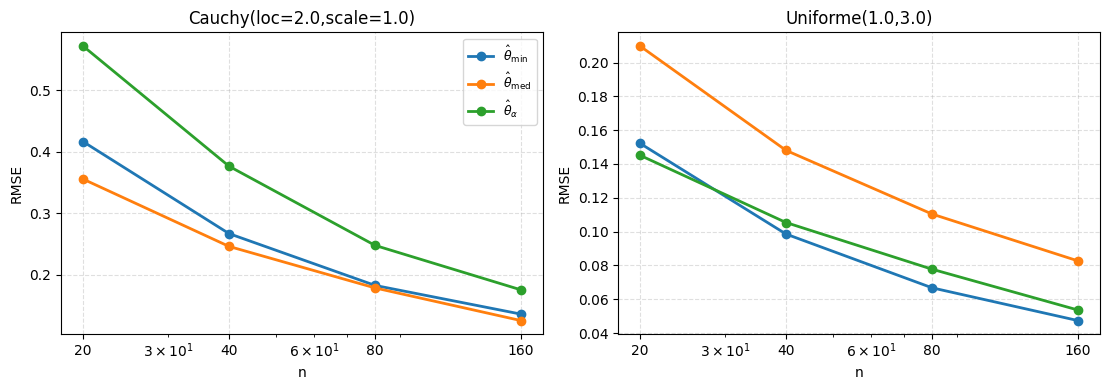

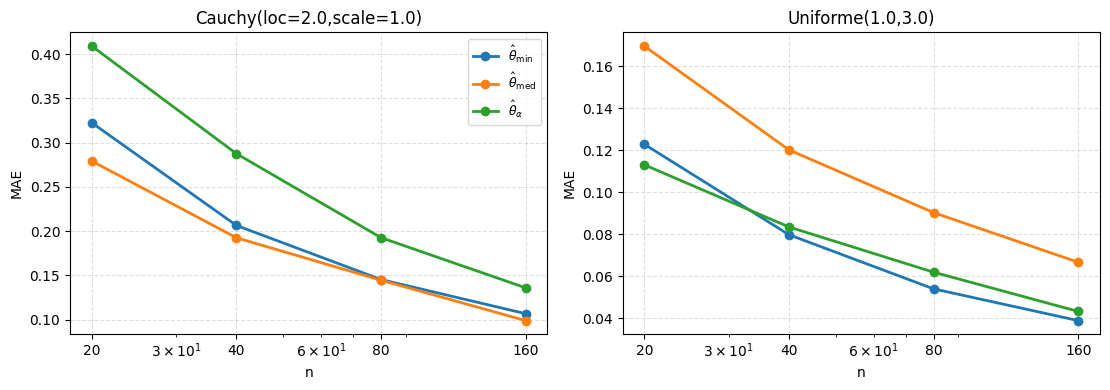

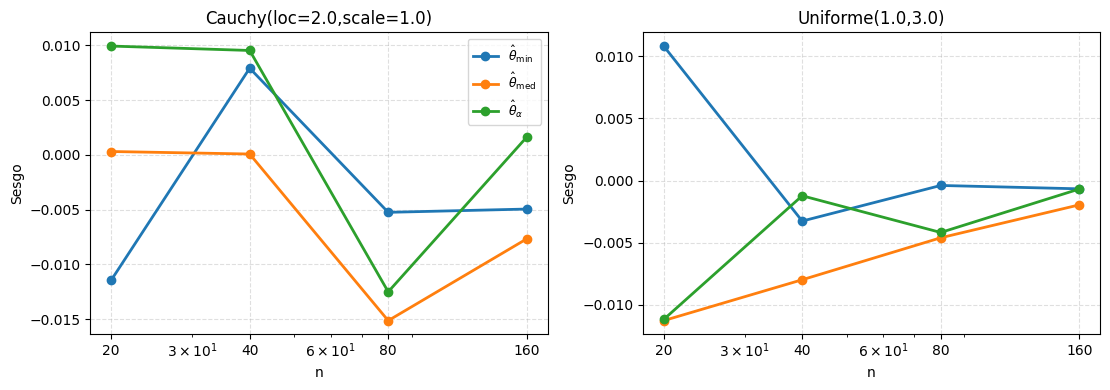

c:\Users\juanc\github\Proyecto2EstadisticaNP\results\figures\theta_estimator_rmse_h0.png
c:\Users\juanc\github\Proyecto2EstadisticaNP\results\figures\theta_estimator_mae_h0.png
c:\Users\juanc\github\Proyecto2EstadisticaNP\results\figures\theta_estimator_bias_h0.png


In [5]:
def plot_metric_h0(metric: str, ylabel: str, filename: str):
    dists = sorted(h0['dist'].unique())
    fig, axes = plt.subplots(1, len(dists), figsize=(5.6 * len(dists), 4), squeeze=False)

    for ax, dist in zip(axes[0], dists):
        sub = h0[h0['dist'] == dist]
        for est in ESTIMATOR_ORDER:
            s = sub[sub['estimator'] == est].sort_values('n')
            ax.plot(
                s['n'], s[metric], marker='o', linewidth=2,
                color=ESTIMATOR_COLORS[est], label=ESTIMATOR_LABELS[est]
            )
        ax.set_xscale('log')
        ax.set_xticks(sorted(sub['n'].unique()))
        ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
        ax.set_title(dist)
        ax.set_xlabel('n')
        ax.set_ylabel(ylabel)
        ax.grid(True, linestyle='--', alpha=0.4)

    axes[0, 0].legend(fontsize=9)
    fig.tight_layout()
    out = FIG_DIR / filename
    fig.savefig(out, dpi=160, bbox_inches='tight')
    plt.show()
    return out

rmse_fig = plot_metric_h0('rmse', 'RMSE', 'theta_estimator_rmse_h0.png')
mae_fig = plot_metric_h0('mae', 'MAE', 'theta_estimator_mae_h0.png')
bias_fig = plot_metric_h0('bias', 'Sesgo', 'theta_estimator_bias_h0.png')
print(rmse_fig)
print(mae_fig)
print(bias_fig)

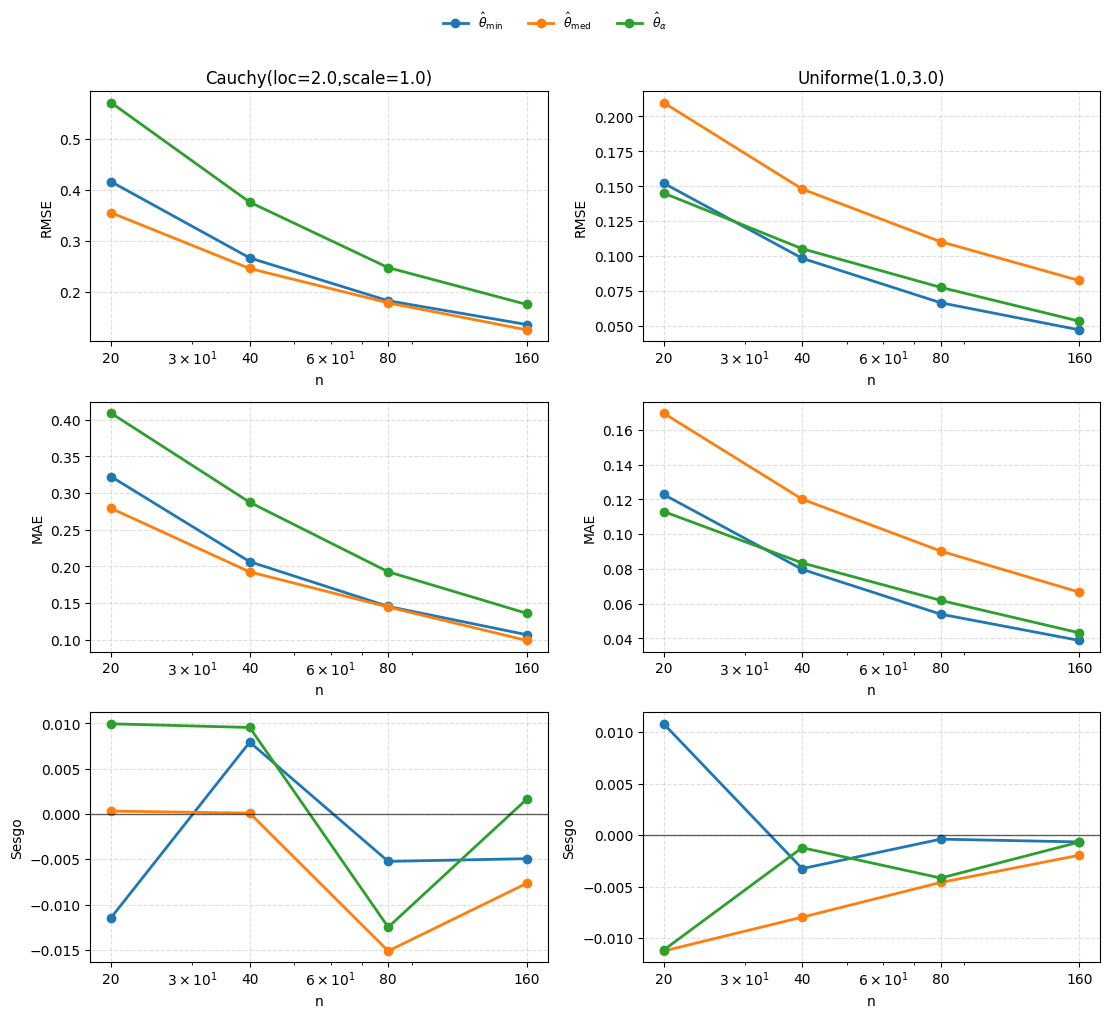

c:\Users\juanc\github\Proyecto2EstadisticaNP\results\figures\theta_estimators_h0_all_metrics.png


In [9]:
def plot_all_metrics_h0(filename: str = "theta_estimators_h0_all_metrics.png"):
    metrics = [
        ("rmse", "RMSE"),
        ("mae", "MAE"),
        ("bias", "Sesgo"),
    ]
    dists = sorted(h0["dist"].unique())

    fig, axes = plt.subplots(
        len(metrics),
        len(dists),
        figsize=(5.6 * len(dists), 3.4 * len(metrics)),
        squeeze=False,
    )

    for row, (metric, ylabel) in enumerate(metrics):
        for col, dist in enumerate(dists):
            ax = axes[row, col]
            sub = h0[h0["dist"] == dist]

            for est in ESTIMATOR_ORDER:
                s = sub[sub["estimator"] == est].sort_values("n")
                ax.plot(
                    s["n"],
                    s[metric],
                    marker="o",
                    linewidth=2,
                    color=ESTIMATOR_COLORS[est],
                    label=ESTIMATOR_LABELS[est],
                )

            ax.set_xscale("log")
            ax.set_xticks(sorted(sub["n"].unique()))
            ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
            ax.set_xlabel("n")
            ax.set_ylabel(ylabel)
            ax.grid(True, linestyle="--", alpha=0.4)

            if row == 0:
                ax.set_title(dist)

            if metric == "bias":
                ax.axhline(0, color="black", linewidth=1, alpha=0.6)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=len(labels),
        fontsize=9,
        frameon=False,
    )

    fig.tight_layout(rect=(0, 0, 1, 0.95))
    out = FIG_DIR / filename
    fig.savefig(out, dpi=160, bbox_inches="tight")
    plt.show()
    return out


theta_h0_all_fig = plot_all_metrics_h0()
print(theta_h0_all_fig)

## Distribucion de errores bajo $H_0$

Esta grafica usa los datos crudos de la simulacion para ver dispersion y outliers de $\hat\theta - \theta$.

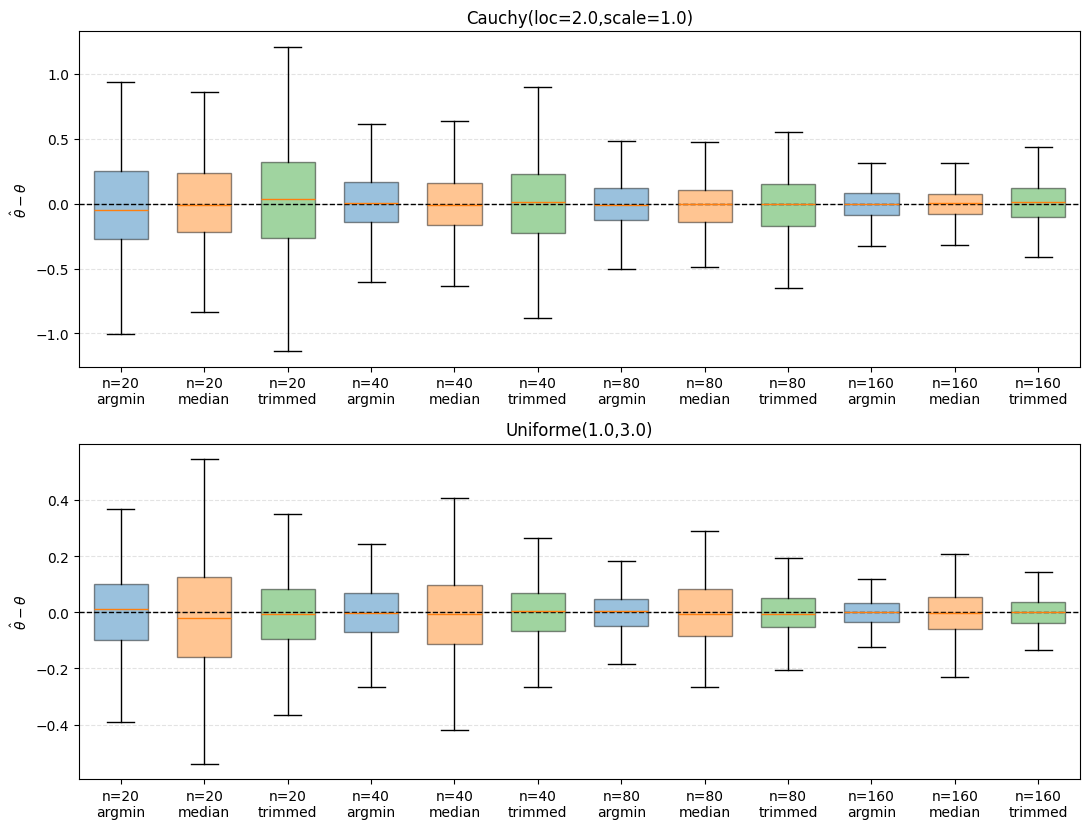

c:\Users\juanc\github\Proyecto2EstadisticaNP\results\figures\theta_estimator_error_boxplots_h0.png


In [6]:
raw_h0 = raw[raw['under_h0']].copy()
raw_h0['error'] = raw_h0['theta_hat'] - raw_h0['theta_true']
raw_h0['estimator'] = pd.Categorical(raw_h0['estimator'], ESTIMATOR_ORDER, ordered=True)

dists = sorted(raw_h0['dist'].unique())
fig, axes = plt.subplots(len(dists), 1, figsize=(11, 4.2 * len(dists)), squeeze=False)

for ax, dist in zip(axes[:, 0], dists):
    sub = raw_h0[raw_h0['dist'] == dist]
    data = [sub[(sub['n'] == n) & (sub['estimator'] == est)]['error'].values
            for n in sorted(sub['n'].unique()) for est in ESTIMATOR_ORDER]
    positions = np.arange(len(data))
    bp = ax.boxplot(data, positions=positions, widths=0.65, showfliers=False, patch_artist=True)
    for patch, est in zip(bp['boxes'], ESTIMATOR_ORDER * len(sorted(sub['n'].unique()))):
        patch.set_facecolor(ESTIMATOR_COLORS[est])
        patch.set_alpha(0.45)
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.set_title(dist)
    ax.set_ylabel(r'$\hat\theta - \theta$')
    ax.set_xticks(positions)
    ax.set_xticklabels([f'n={n}\n{est}' for n in sorted(sub['n'].unique()) for est in ESTIMATOR_ORDER], rotation=0)
    ax.grid(True, axis='y', linestyle='--', alpha=0.35)

fig.tight_layout()
error_fig = FIG_DIR / 'theta_estimator_error_boxplots_h0.png'
fig.savefig(error_fig, dpi=160, bbox_inches='tight')
plt.show()
print(error_fig)

## Diagnostico bajo $H_a$

En distribuciones asimetricas no hay un $\theta$ verdadero de simetria. Por eso no se calcula RMSE contra un centro real. Aqui solo se revisa la estabilidad de cada estimador mediante desviacion estandar e intervalo intercuartilico.

,std_hat,iqr
estimator,,
trimmed,0.118864,0.157631
argmin,0.124780,0.166093
median,0.130413,0.172746


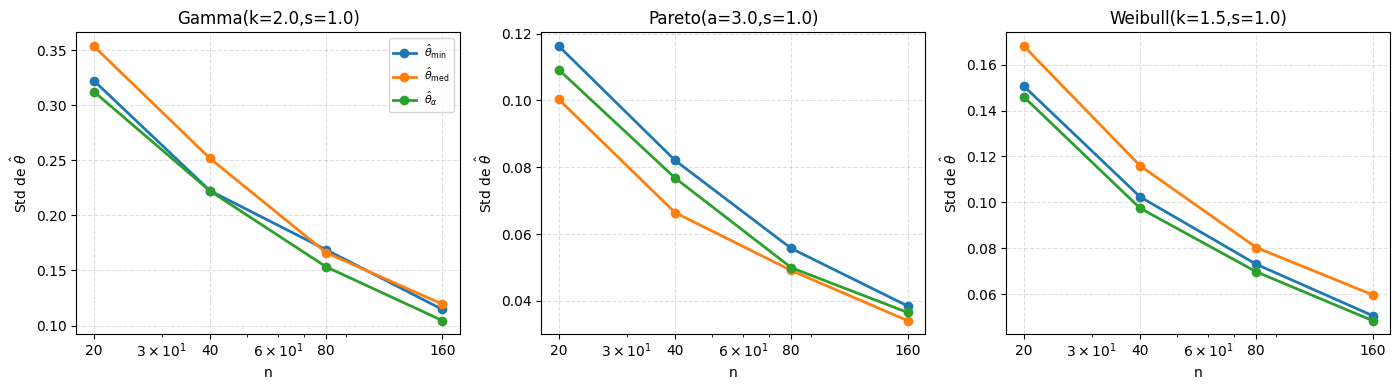

c:\Users\juanc\github\Proyecto2EstadisticaNP\results\figures\theta_estimator_std_ha.png


In [7]:
ha = summary[~summary['under_h0']].copy()
if {'q25', 'q75'}.issubset(ha.columns):
    ha['iqr'] = ha['q75'] - ha['q25']
else:
    q = (
        raw[~raw['under_h0']]
        .groupby(['dist', 'n', 'estimator'])['theta_hat']
        .quantile([0.25, 0.75])
        .unstack()
        .rename(columns={0.25: 'q25', 0.75: 'q75'})
        .reset_index()
    )
    ha = ha.merge(q, on=['dist', 'n', 'estimator'], how='left')
    ha['iqr'] = ha['q75'] - ha['q25']

ha_stability = (
    ha.groupby('estimator')[['std_hat', 'iqr']]
    .mean()
    .loc[ESTIMATOR_ORDER]
    .sort_values('std_hat')
)
display(ha_stability)

dists = sorted(ha['dist'].unique())
fig, axes = plt.subplots(1, len(dists), figsize=(4.7 * len(dists), 4), squeeze=False)
for ax, dist in zip(axes[0], dists):
    sub = ha[ha['dist'] == dist]
    for est in ESTIMATOR_ORDER:
        s = sub[sub['estimator'] == est].sort_values('n')
        ax.plot(s['n'], s['std_hat'], marker='o', linewidth=2, color=ESTIMATOR_COLORS[est], label=ESTIMATOR_LABELS[est])
    ax.set_xscale('log')
    ax.set_xticks(sorted(sub['n'].unique()))
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.set_title(dist)
    ax.set_xlabel('n')
    ax.set_ylabel(r'Std de $\hat\theta$')
    ax.grid(True, linestyle='--', alpha=0.4)
axes[0, 0].legend(fontsize=8)
fig.tight_layout()
ha_fig = FIG_DIR / 'theta_estimator_std_ha.png'
fig.savefig(ha_fig, dpi=160, bbox_inches='tight')
plt.show()
print(ha_fig)

## Conclusion automatica

In [8]:
best_score = mean_ranks.index[0]
best_rmse = mean_metrics.index[0]
rmse_wins = winners_long[winners_long['metric'] == 'rmse']['estimator'].value_counts().reindex(ESTIMATOR_ORDER, fill_value=0)

cauchy_winners = (
    winners_long[(winners_long['metric'] == 'rmse') & (winners_long['dist'].str.contains('Cauchy'))]
    .sort_values('n')[['n', 'estimator', 'value']]
)
uniform_winners = (
    winners_long[(winners_long['metric'] == 'rmse') & (winners_long['dist'].str.contains('Uniforme'))]
    .sort_values('n')[['n', 'estimator', 'value']]
)

display(Markdown(f'''
**Decision principal:** con estos resultados, el mejor estimador global de $\theta$ es `{best_score}`.

- Por promedio de RMSE bajo $H_0$, gana `{best_rmse}`.
- Por ranking compuesto (60% RMSE, 30% MAE, 10% sesgo absoluto), gana `{best_score}`.
- Victorias en RMSE por escenario `(distribucion, n)`: `{rmse_wins.to_dict()}`.

**Matiz importante:** en Cauchy, la mediana suele ser mejor por robustez frente a colas pesadas. En Uniforme, `argmin` domina para muestras medianas/grandes y `trimmed` puede ganar en $n=20$. Si se necesita una unica opcion para los tests del proyecto, `argmin` es la recomendacion global; si se prioriza robustez extrema en colas pesadas, la mediana es una alternativa defensible.
'''))

display(Markdown('### Ganadores RMSE en Cauchy'))
display(cauchy_winners)
display(Markdown('### Ganadores RMSE en Uniforme'))
display(uniform_winners)


**Decision principal:** con estos resultados, el mejor estimador global de $	heta$ es `argmin`.

- Por promedio de RMSE bajo $H_0$, gana `argmin`.
- Por ranking compuesto (60% RMSE, 30% MAE, 10% sesgo absoluto), gana `argmin`.
- Victorias en RMSE por escenario `(distribucion, n)`: `{'argmin': 3, 'median': 4, 'trimmed': 1}`.

**Matiz importante:** en Cauchy, la mediana suele ser mejor por robustez frente a colas pesadas. En Uniforme, `argmin` domina para muestras medianas/grandes y `trimmed` puede ganar en $n=20$. Si se necesita una unica opcion para los tests del proyecto, `argmin` es la recomendacion global; si se prioriza robustez extrema en colas pesadas, la mediana es una alternativa defensible.


### Ganadores RMSE en Cauchy

,n,estimator,value
0,20,median,0.355701
1,40,median,0.246370
2,80,median,0.178981
3,160,median,0.125934


### Ganadores RMSE en Uniforme

,n,estimator,value
4,20,trimmed,0.145115
5,40,argmin,0.098541
6,80,argmin,0.066761
7,160,argmin,0.047365
